In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp
from IPython.display import display, Math

N_BINS = 20
all_r2 = []

for bin_idx in range(N_BINS):
    BIN_IDX = bin_idx
    RESIDUAL_MODE = False
    N_FREE_PARAMS = 3
    LENGTH_LOC_ARG = 10
    LENGTH_SCALE_ARG = 5
    SEED = 42

    folder_name = (
        "/Users/arnablahiry/repos/SymReg-L1-Norm/L1NORM_SR_bin%d_of%d_res%i_fp%d_lloc%d_lscale%d_s%d"
        % (BIN_IDX, N_BINS, int(RESIDUAL_MODE), N_FREE_PARAMS,
           LENGTH_LOC_ARG, LENGTH_SCALE_ARG, SEED)
    )

    file_pareto = os.path.join(folder_name, 'sr_curves_pareto.csv')
    file_pareto_pandas = pd.read_csv(file_pareto).iloc[-1]
    all_r2.append(file_pareto_pandas['r2'])
    equation = file_pareto_pandas['expression']
    print(equation)

    # Define ALL symbols that appear in the expressions
    c0, c1, c2 = sp.symbols('c0 c1 c2')
    Omega_m, sigma_8, w = sp.symbols('Omega_m sigma_8 w')

    # Parse and substitute
    expr = sp.sympify(equation)
    expr_substituted = expr.subs({
        c0: sp.Float(file_pareto_pandas['c0'], 2),
        c1: sp.Float(file_pareto_pandas['c1'], 2),
        c2: sp.Float(file_pareto_pandas['c2'], 2),
    })

    #display(Math(sp.latex(expr_substituted)))
    #display(equation)
    print('\n')

((exp((c2+(((Omega_m--(((c2+c2)*sigma_8)))+c1)+sigma_8)))+c0)+c2)


exp(((((sigma_8*c1)*(Omega_m+(((c0+c0)+c1)+sigma_8)))+c0)+Omega_m))


exp(((((Omega_m*(c0+((((Omega_m+Omega_m)+sigma_8)+c2)+c0)))*c0)+c1)+sigma_8))


((((exp(c1)+exp(((((sigma_8*c0)+(Omega_m+(c1*Omega_m)))*c0)+c0)))+c2))**(2))


((((((sigma_8+(((((sigma_8+sigma_8)+c1)*c0)*Omega_m)+c2))+c2)*c0)+c2))**(2))


((((sigma_8+(((sigma_8+((c1*(c1*(Omega_m+sigma_8)))+c1))*c2)+c0)))**(2))+c0)


(((-(((((((Omega_m*Omega_m)*c0)+sigma_8)*c2)+Omega_m)+c1))*c0)+c1)*c2)


(c1-(c0/((c2+(((((c1+((Omega_m+sigma_8)+c0))+c2))**(2))*c1))+c1)))


((((sigma_8/c1)-exp(-((Omega_m*-(c0)))))*c1)*c2)


(c2+(c0+((((((sigma_8+(Omega_m+c1))+c1)*c2)+w)+c2)*c1)))


(((((sigma_8+((c2+c2)+Omega_m))/((c1)**(-1)))/exp((w*c0))))**(-1))


(((exp((((((((c2+sigma_8)+Omega_m))**(0.5))+c1)+c1)+c1))*c0)+c1)+c2)


((-((((c1-(((c0+(c0+c2))*(Omega_m+sigma_8))+c0)))**(2)))+c0)+c0)


(((c1*((sigma_8+(((Omega_m*(sigma_8+c0))+sigma_8)*c2))+Omega_m))+1.0)*c2)


(((((((sig

In [3]:
import os
import re
import numpy as np
import pandas as pd
import sympy as sp
from IPython.display import display, Math

# ── Define symbolic variables ──────────────────────────────────────────────
Omega_m, sigma_8, w, c0, c1, c2 = sp.symbols(
    "Omega_m sigma_8 w c0 c1 c2", real=True
)
SYMPY_VARS = {
    "Omega_m": Omega_m,
    "sigma_8": sigma_8,
    "w":       w,
    "c0":      c0,
    "c1":      c1,
    "c2":      c2,
}

# ── Settings ───────────────────────────────────────────────────────────────
N_BINS          = 20
N_FREE_PARAMS   = 3
LENGTH_LOC_ARG  = 10
LENGTH_SCALE_ARG = 5
SEED            = 42
RESIDUAL_MODE   = False

all_r2        = []
all_equations = []          # sympy Expr objects
all_functions = []          # numpy-callable lambdas

rows = [-3,-4, 3, 3, -2, -3, 3, -1, -1, -2, 3, -1, -1, -1, -4, -2, 3, -1, -1, -1]
for bin_idx in range(N_BINS):
    folder_name = (
        "/Users/arnablahiry/repos/SymReg-L1-Norm/"
        "L1NORM_SR_bin%d_of%d_res%i_fp%d_lloc%d_lscale%d_s%d"
        % (bin_idx, N_BINS, int(RESIDUAL_MODE), N_FREE_PARAMS,
           LENGTH_LOC_ARG, LENGTH_SCALE_ARG, SEED)
    )

    file_pareto = os.path.join(folder_name, "sr_curves_pareto.csv")
    row         = pd.read_csv(file_pareto).iloc[rows[bin_idx]]

    all_r2.append(row["r2"])
    raw_expr: str = row["expression"]

    # ── Parse the expression string into a sympy Expr ─────────────────────
    # sympify understands most standard math notation; pass our symbol dict
    # so it maps bare names like "Omega_m" to the sympy Symbols above.
    try:
        sym_expr = sp.sympify(raw_expr, locals=SYMPY_VARS)
    except Exception as e:
        print(f"  [bin {bin_idx}] sympify failed ({e}); storing None.")
        sym_expr = None

    all_equations.append(sym_expr)

    # ── Build a fast numpy-callable function via lambdify ─────────────────
    if sym_expr is not None:
        func = sp.lambdify(
            (Omega_m, sigma_8, w, c0, c1, c2),
            sym_expr,
            modules="numpy",        # uses np.sin, np.exp, … automatically
        )
    else:
        func = None

    all_functions.append(func)

    # ── Pretty-print ──────────────────────────────────────────────────────
    print(f"\n── Bin {bin_idx:02d}  (R² = {row['r2']:.4f}) ──")
    print(f"  raw  : {raw_expr}")
    if sym_expr is not None:
        display(Math(sp.latex(sym_expr)))


# ── Example: evaluate bin-0 function at a specific parameter point ─────────
print("\n── Quick evaluation example (bin 0) ──")
if all_functions[0] is not None:
    val = all_functions[0](
        Omega_m=0.3,
        sigma_8=0.8,
        w=-1.0,
        c0=1.0,
        c1=0.0,
        c2=0.0,
    )
    print(f"  f(0.3, 0.8, -1.0, 1.0, 0.0, 0.0) = {val}")


# ── Example: vectorised evaluation over a grid ────────────────────────────
print("\n── Vectorised sweep over Omega_m (bin 0) ──")
if all_functions[0] is not None:
    om_grid = np.linspace(0.1, 0.5, 50)
    y_grid  = all_functions[0](
        Omega_m=om_grid,
        sigma_8=0.8,
        w=-1.0,
        c0=1.0,
        c1=0.0,
        c2=0.0,
    )
    print(f"  Omega_m range : {om_grid[[0, -1]]}")
    print(f"  output  range : {y_grid.min():.4f} … {y_grid.max():.4f}")


── Bin 00  (R² = 0.9206) ──
  raw  : exp(((Omega_m-(((c1*((c1*c1)+c0))-c2)*sigma_8))+c0))


<IPython.core.display.Math object>


── Bin 01  (R² = 0.9472) ──
  raw  : exp(((c1*Omega_m)+(c2+(c0*sigma_8))))


<IPython.core.display.Math object>


── Bin 02  (R² = 0.9386) ──
  raw  : exp((((c1*sigma_8)+c2)+Omega_m))


...


── Bin 18  (R² = 0.6604) ──
  raw  : (((exp((sigma_8+((c0*(((c1+Omega_m)*sigma_8)+Omega_m))+c1)))*c1)*c1)*c1)


<IPython.core.display.Math object>


── Bin 19  (R² = 0.9284) ──
  raw  : (c1*((sigma_8+Omega_m)*exp((((c2*Omega_m)+Omega_m)+(sigma_8+sigma_8)))))


<IPython.core.display.Math object>


── Quick evaluation example (bin 0) ──
  f(0.3, 0.8, -1.0, 1.0, 0.0, 0.0) = 3.6692966676192444

── Vectorised sweep over Omega_m (bin 0) ──
  Omega_m range : [0.1 0.5]
  output  range : 3.0042 … 4.4817


Scaler mean:  [ 0.29813823  0.78352326 -1.01675344]
Scaler scale: [0.04623465 0.06923493 0.09095736]
Bin 00 | R²=0.6606 | c0=-8.8315 c1=2.9441 c2=0.8129
Bin 01 | R²=0.7974 | c0=1.1902 c1=0.8997 c2=-7.6222
Bin 02 | R²=0.8858 | c0=1.0000 c1=1.1366 c2=-6.6606
Bin 03 | R²=0.9187 | c0=-5.3743 c1=0.7217 c2=1.0000
Bin 04 | R²=0.9495 | c0=0.0620 c1=0.4091 c2=0.8760
Bin 05 | R²=0.9570 | c0=1.1913 c1=0.0420 c2=3.4730
Bin 06 | R²=0.9435 | c0=0.1093 c1=1.0000 c2=-0.0315
Bin 07 | R²=0.8849 | c0=0.8549 c1=0.2731 c2=3.6578
Bin 08 | R²=0.8402 | c0=-0.0135 c1=41.8812 c2=-0.0051
Bin 09 | R²=0.9415 | c0=0.0149 c1=0.9346 c2=5.2158
Bin 10 | R²=0.9169 | c0=0.1108 c1=0.0120 c2=0.0112
Bin 11 | R²=nan | c0=-0.0355 c1=-0.6070 c2=0.8617
Bin 12 | R²=0.8930 | c0=0.1261 c1=0.3450 c2=-0.1845
Bin 13 | R²=0.9469 | c0=0.2169 c1=0.3467 c2=0.1021
Bin 14 | R²=0.9634 | c0=5.7768 c1=2.2397 c2=189.7029
Bin 15 | R²=0.9512 | c0=-0.0691 c1=-13.8418 c2=8.7590
Bin 16 | R²=0.9155 | c0=1.0000 c1=0.1747 c2=-3.3640
Bin 17 | R²=0.8580

<lambdifygenerated-72>:2: RuntimeWarning: invalid value encountered in sqrt
  return c0*exp(3*c1 + (Omega_m + c2 + sigma_8)**0.5) + c1 + c2


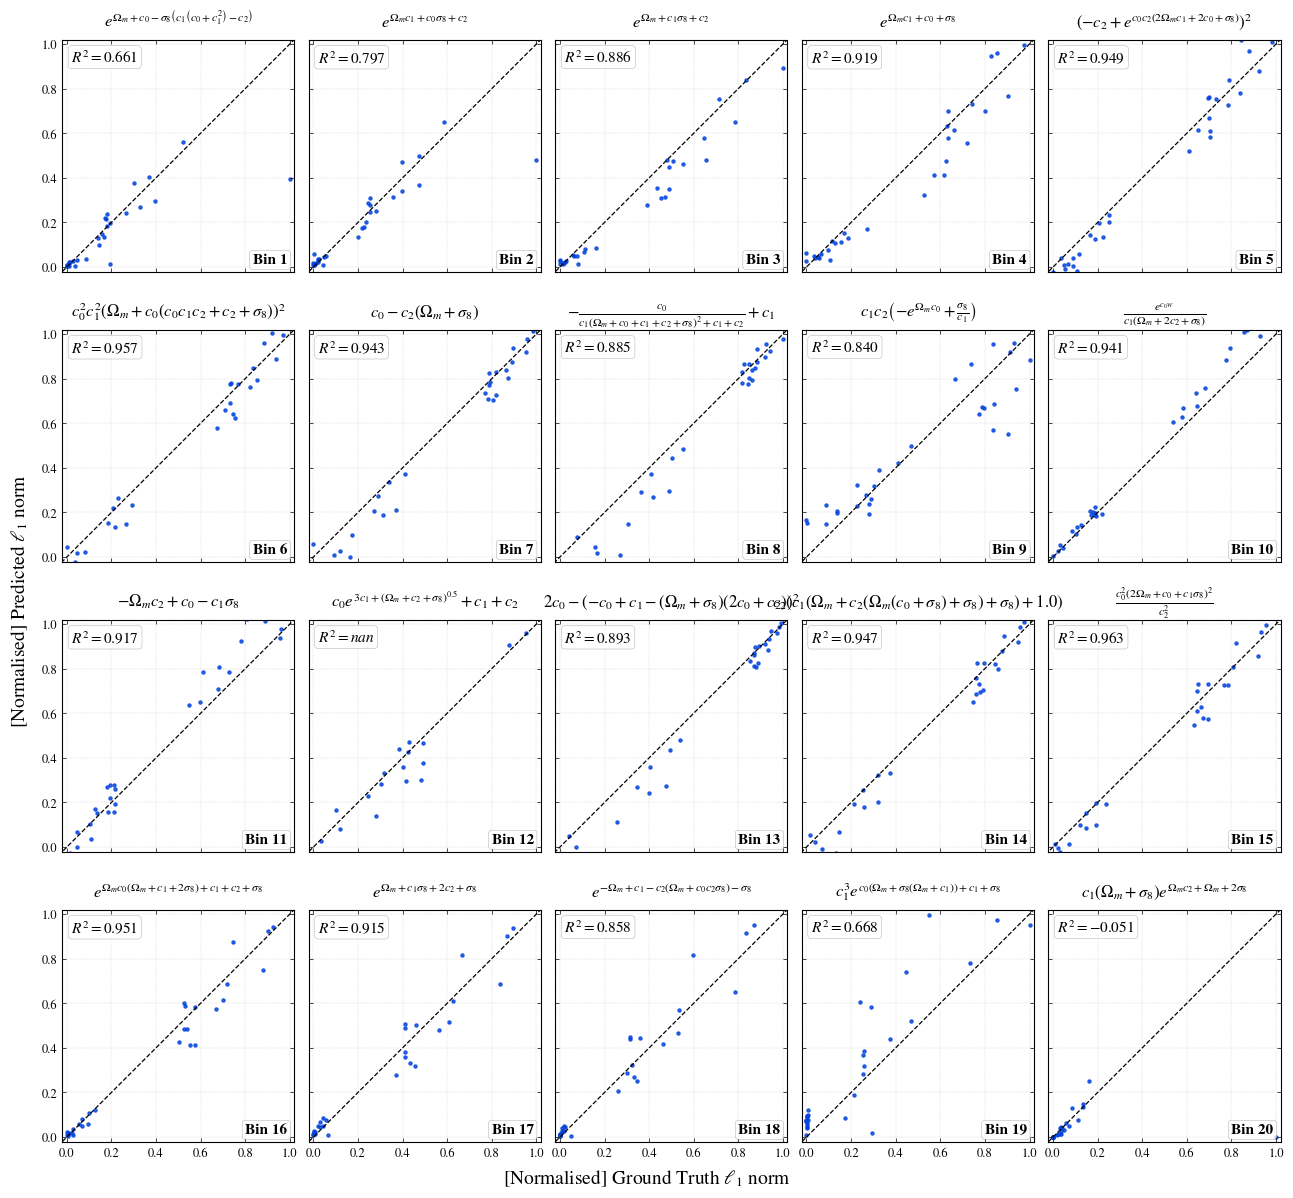

In [9]:
import os
import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ── Global matplotlib settings ───────────────────────────────────────────────
from matplotlib import font_manager

plt.rcParams.update({
    "text.usetex":     False,          # use mathtext throughout, not pdflatex
    "font.family":     "serif",
    "font.serif":      ["STIXGeneral", "DejaVu Serif", "Times New Roman", "serif"],
    "mathtext.fontset": "stix",        # STIX looks like Computer Modern in mathtext
    "font.size":           8,
    "axes.labelsize":      8,
    "xtick.labelsize":     7,
    "ytick.labelsize":     7,
})

# ── Helper: sympy expr → short LaTeX title, split into 2 lines if long ───────
def latex_title(sym_expr, max_len=32):
    s = sp.latex(sym_expr)
    if len(s) <= max_len:
        return f"${s}$"
    mid = len(s) // 2
    split = -1
    for offset in range(mid):
        for idx in [mid + offset, mid - offset]:
            if 0 < idx < len(s) and s[idx] in ('+', '-'):
                split = idx
                break
        if split >= 0:
            break
    if split < 0:
        split = max_len
    l1 = s[:split].rstrip()
    l2 = s[split:].lstrip()
    return r"$\substack{" + l1 + r" \\ " + l2 + r"}$"

# ── 1. Load data ─────────────────────────────────────────────────────────────
#csv_data = pd.read_csv('/Users/arnablahiry/repos/SR_project/data/csv/l1norm_training_data_b20.csv')
import pickle

f_df_test = '/Users/arnablahiry/repos/SymReg-L1-Norm/df_test.pkl'
with open(f_df_test, 'rb') as f:
    csv_data = pickle.load(f)

Om_data = csv_data['Omega_m'].to_numpy()
s8_data = csv_data['sigma_8'].to_numpy()
w_data  = csv_data['w'].to_numpy()

# ── 2. StandardScaler ────────────────────────────────────────────────────────
X_raw    = np.stack([Om_data, s8_data, w_data], axis=1)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

Om_scaled = X_scaled[:, 0]
s8_scaled = X_scaled[:, 1]
w_scaled  = X_scaled[:, 2]

print(f"Scaler mean:  {scaler.mean_}")
print(f"Scaler scale: {scaler.scale_}")

# ── 3. Sympy symbols ─────────────────────────────────────────────────────────
_Om, _s8, _w, _c0, _c1, _c2 = sp.symbols(
    "Omega_m sigma_8 w c0 c1 c2", real=True
)
SYMPY_VARS = {
    "Omega_m": _Om, "sigma_8": _s8, "w": _w,
    "c0": _c0,      "c1": _c1,      "c2": _c2,
}

# ── 4. Numpy map ─────────────────────────────────────────────────────────────
NUMPY_MAP = [
    {
        "exp":   np.exp,   "log":   np.log,   "log2":  np.log2,
        "log10": np.log10, "sqrt":  np.sqrt,  "abs":   np.abs,
        "Abs":   np.abs,   "sin":   np.sin,   "cos":   np.cos,
        "tan":   np.tan,   "tanh":  np.tanh,  "sinh":  np.sinh,
        "cosh":  np.cosh,  "sign":  np.sign,
    },
    "numpy",
]

# ── 5. Settings ──────────────────────────────────────────────────────────────
N_BINS           = 20
N_FREE_PARAMS    = 3
LENGTH_LOC_ARG   = 10
LENGTH_SCALE_ARG = 5
SEED             = 42
RESIDUAL_MODE    = False

rows = [-3,-4, 3, 3, -2, -3, 3, -1, -1, -2, 3, -1, -1, -1, -4, -2, 3, -1, -1, -1]

all_equations = []
all_functions = []
all_results   = []
all_gt        = []
all_r2        = []

# ── Figure 1: per-bin scatter ────────────────────────────────────────────────
fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(13, 12),
                         sharex=True, sharey=True)
axes_flat = axes.flatten()

# ── Helper: safe per-axes equation title ─────────────────────────────────────
def set_eq_title(ax, i, sym_expr):
    if i==4 or i==5 or i==9 or i ==11 or i ==13 or i ==14:
        fontsize=12
        pad=10
    else:
        fontsize=12
        pad=10
    raw = sp.latex(sym_expr)
    ax.set_title(f"${raw}$", fontsize=fontsize, pad=pad)
    ax.title.set(usetex=False)

    
for bin_idx in range(N_BINS):

    gt = csv_data[f'bin_{bin_idx}'].to_numpy().astype(float)

    folder_name = (
        "/Users/arnablahiry/repos/SymReg-L1-Norm/"
        "L1NORM_SR_bin%d_of%d_res%i_fp%d_lloc%d_lscale%d_s%d"
        % (bin_idx, N_BINS, int(RESIDUAL_MODE), N_FREE_PARAMS,
           LENGTH_LOC_ARG, LENGTH_SCALE_ARG, SEED)
    )

    csv_row = pd.read_csv(
        os.path.join(folder_name, "sr_curves_pareto.csv")
    ).iloc[rows[bin_idx]]

    c0_val = float(csv_row['c0'])
    c1_val = float(csv_row['c1'])
    c2_val = float(csv_row['c2'])

    # ── Parse & lambdify ─────────────────────────────────────────────────────
    try:
        sym_expr = sp.sympify(csv_row["expression"], locals=SYMPY_VARS)
    except Exception as e:
        raise RuntimeError(f"[bin {bin_idx}] sympify failed: {e}")

    all_equations.append(sym_expr)

    func = sp.lambdify(
        (_Om, _s8, _w, _c0, _c1, _c2),
        sym_expr,
        modules=NUMPY_MAP,
    )
    all_functions.append(func)

    # ── Evaluate ─────────────────────────────────────────────────────────────
    pred = func(Om_scaled, s8_scaled, w_scaled, c0_val, c1_val, c2_val)
    pred = np.asarray(pred, dtype=float).ravel()

    # ── Normalise gt → [0,1]; apply same shift+scale to pred ─────────────────
    gt_min, gt_max = gt.min(), gt.max()
    gt_n   = (gt   - gt_min) / (gt_max - gt_min)
    pred_n = (pred - gt_min) / (gt_max - gt_min)

    all_results.append(pred)
    all_gt.append(gt)

    r2 = 1 - np.sum((gt - pred)**2) / np.sum((gt - np.mean(gt))**2)
    all_r2.append(r2)

    print(f"Bin {bin_idx:02d} | R²={r2:.4f} | "
          f"c0={c0_val:.4f} c1={c1_val:.4f} c2={c2_val:.4f}")

    # ── Plot ──────────────────────────────────────────────────────────────────
    col = bin_idx % 5
    row = bin_idx // 5
    ax  = axes_flat[bin_idx]

    lo = min(gt_n.min(), pred_n.min()) - 0.02
    hi = max(gt_n.max(), pred_n.max()) + 0.02

    ax.scatter(gt_n, pred_n, s=5, alpha=0.8, color="xkcd:blue", rasterized=True)
    ax.plot([lo, hi], [lo, hi], "k--", lw=0.9)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal")
    ax.grid(True, lw=0.3, ls="--", alpha=0.35, color="gray")
    ax.tick_params(which="both", top=True, right=True,
                   direction="in", length=3, width=0.5,
                   labelleft=(col == 0), labelbottom=(row == 3),
                   labelsize=9)

    # ── Bin label (bottom-right) ─────────────────────────────────────────────────
    ax.text(0.97, 0.08, rf"Bin {bin_idx + 1}",
            transform=ax.transAxes, fontsize=11,
            va="top", ha="right", weight='bold',
            bbox=dict(boxstyle="round,pad=0.2", fc="white",
                      ec="gray", lw=0.3, alpha=0.75))

    # ── R² label (top-left) ──────────────────────────────────────────────────
    ax.text(0.04, 0.96, rf"$R^2={r2:.3f}$",
            transform=ax.transAxes, fontsize=11,
            va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.2", fc="white",
                      ec="gray", lw=0.3, alpha=0.75))

    # ── Equation as title ─────────────────────────────────────────────────────
    set_eq_title(ax, bin_idx, sym_expr)


fig.supxlabel(r"[Normalised] Ground Truth $\ell_1$ norm", fontsize=14,y=0.01)
fig.supylabel(r"[Normalised] Predicted $\ell_1$ norm", fontsize=14,x=0.01)

plt.tight_layout(h_pad=2.5, w_pad=0.5)
fig.savefig("per_bin_sr_plot.pdf", bbox_inches="tight", dpi=200)
plt.show()



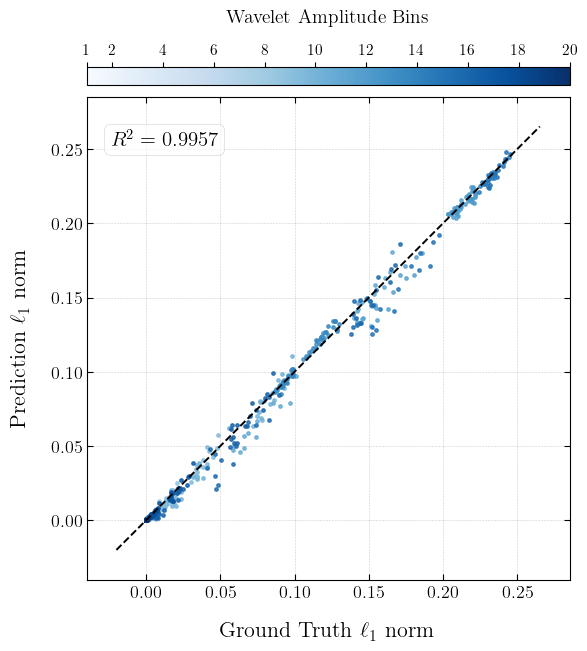

In [14]:
# ── Combined plot ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "text.usetex":        True,
    "font.family":        "serif",
    "font.serif":         ["Computer Modern Roman"],
    "font.size":          14,
    "axes.labelsize":     16,
    "axes.titlesize":     16,
    "xtick.labelsize":    13,
    "ytick.labelsize":    13,
    "legend.fontsize":    13,
})

fig_comb, ax_comb = plt.subplots(figsize=(6, 6))

cmap  = plt.cm.Blues
N_shy = N_BINS - 1

for bin_idx in range(N_BINS):
    color = cmap(0.3 + 0.7 * bin_idx / N_shy)
    ax_comb.scatter(all_gt[bin_idx], all_results[bin_idx],
                    s=6, alpha=0.8, color=color, rasterized=True)



# ── Prediction = truth line ───────────────────────────────────────────────────
all_gt_cat   = np.concatenate(all_gt)
all_pred_cat = np.concatenate(all_results)
lo = min(all_gt_cat.min()-0.02, all_pred_cat.min()-0.02)
hi = max(all_gt_cat.max()+0.02, all_pred_cat.max()+0.02)
ax_comb.plot([lo, hi], [lo, hi], "k--", lw=1.4, zorder=5)

# ── Global R² ────────────────────────────────────────────────────────────────

mask = np.isfinite(all_gt_cat) & np.isfinite(all_pred_cat)

gt   = all_gt_cat[mask]
pred = all_pred_cat[mask]

r2_global = 1 - np.sum((gt - pred)**2) / np.sum((gt - np.mean(gt))**2)

ax_comb.text(0.05, 0.93,
             rf"$R^2 = {r2_global:.4f}$",
             transform=ax_comb.transAxes,
             fontsize=15, va="top",
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", linewidth=0.2, alpha=0.7))

# ── Axes ──────────────────────────────────────────────────────────────────────

ax_comb.set_xlim(lo-0.02, hi+0.02)
ax_comb.set_ylim(lo-0.02, hi+0.02)

ax_comb.set_xlabel(r"Ground Truth $\ell_1$ norm", labelpad=15)
ax_comb.set_ylabel(r"Prediction $\ell_1$ norm", labelpad=15)
ax_comb.set_aspect("equal")

ax_comb.tick_params(which="both", top=True, right=True,
                    direction="in", length=4, width=0.8)
ax_comb.grid(True, lw=0.4, ls="--", alpha=0.4, color="gray")

# ── Colorbar above the plot (aligned to axes borders) ────────────────────────
plt.tight_layout()   # call first so ax positions are finalised

pos  = ax_comb.get_position()          # [x0, y0, width, height] in figure coords
cax  = fig_comb.add_axes([pos.x0, pos.y1 + 0.02, pos.width, 0.03])

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0.3, vmax=1.0))
sm.set_array([])

tick_indices = [0, 1,3,5,7,9,11,13,15,17,19]
tick_vals    = [0.3 + 0.7 * i / N_shy for i in tick_indices]
tick_labels  = [str(i + 1) for i in tick_indices]

cbar = fig_comb.colorbar(sm, cax=cax, orientation="horizontal")
cbar.set_ticks(tick_vals)
cbar.set_ticklabels(tick_labels, fontsize=11)
cbar.set_label(r"Wavelet Amplitude Bins", fontsize=14, labelpad=15)
cax.xaxis.set_ticks_position("top")
cax.xaxis.set_label_position("top")

fig_comb.savefig("combined_sr_plot.pdf", bbox_inches="tight", dpi=200)
plt.show()

In [15]:
'''# ── Custom R² colormap: red → orange → blue ───────────────────────────────────
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

r2_cmap = LinearSegmentedColormap.from_list(
    "r2_custom",
    [
        (0.0,  "#d62728"),   # red       at R²=0.00
        (0.5,  "#ff7f0e"),   # orange    at R²=0.50
        (0.8,  "#ff7f0e"),   # orange    at R²=0.80  ← hold orange until 0.80
        (1.0,  "#0343df"),   # xkcd blue at R²=1.00
    ]
)

# ── Figure 3: R² bar chart ────────────────────────────────────────────────────
fig_r2, ax_r2 = plt.subplots(figsize=(10, 4.2))

norm_r2 = Normalize(vmin=0, vmax=1)
bar_colors = [r2_cmap(norm_r2(r)) for r in all_r2]

bars = ax_r2.bar(range(N_BINS), all_r2, color=bar_colors,
                 edgecolor="white", linewidth=0.5)

ax_r2.axhline(1.0, color="k",         lw=1.1, ls="--")
ax_r2.axhline(0.9, color='lightblue',       lw=1, ls="--", label=r"$R^2=0.90$")
ax_r2.axhline(0.7, color='orange',       lw=1, ls="--", label=r"$R^2=0.70$")
ax_r2.set_xticks(range(N_BINS))
ax_r2.set_xticklabels([rf"$b_{{{i+1}}}$" for i in range(N_BINS)], fontsize=10)
ax_r2.set_ylabel(r"$R^2$", fontsize=12)
ax_r2.set_ylim(min(0, min(all_r2)) - 0.05, 1.05)
ax_r2.legend(fontsize=9)
ax_r2.tick_params(which="both", top=True, right=True, direction="in")
ax_r2.grid(True, lw=0.3, ls="--", alpha=0.35, color="gray", axis="y")

# ── Colorbar ──────────────────────────────────────────────────────────────────
sm = ScalarMappable(cmap=r2_cmap, norm=norm_r2)
sm.set_array([])
cbar = fig_r2.colorbar(sm, ax=ax_r2, orientation="vertical",
                        fraction=0.02, pad=0.02)
cbar.set_label(r"$R^2$", fontsize=11)
cbar.set_ticks([0, 0.5, 0.7, 0.8, 0.9, 1.0])
cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
fig_r2.savefig("r2_bar_chart.pdf", bbox_inches="tight", dpi=200)
plt.show()'''

'# ── Custom R² colormap: red → orange → blue ───────────────────────────────────\nfrom matplotlib.colors import LinearSegmentedColormap, Normalize\nfrom matplotlib.cm import ScalarMappable\n\nr2_cmap = LinearSegmentedColormap.from_list(\n    "r2_custom",\n    [\n        (0.0,  "#d62728"),   # red       at R²=0.00\n        (0.5,  "#ff7f0e"),   # orange    at R²=0.50\n        (0.8,  "#ff7f0e"),   # orange    at R²=0.80  ← hold orange until 0.80\n        (1.0,  "#0343df"),   # xkcd blue at R²=1.00\n    ]\n)\n\n# ── Figure 3: R² bar chart ────────────────────────────────────────────────────\nfig_r2, ax_r2 = plt.subplots(figsize=(10, 4.2))\n\nnorm_r2 = Normalize(vmin=0, vmax=1)\nbar_colors = [r2_cmap(norm_r2(r)) for r in all_r2]\n\nbars = ax_r2.bar(range(N_BINS), all_r2, color=bar_colors,\n                 edgecolor="white", linewidth=0.5)\n\nax_r2.axhline(1.0, color="k",         lw=1.1, ls="--")\nax_r2.axhline(0.9, color=\'lightblue\',       lw=1, ls="--", label=r"$R^2=0.90$")\nax_r2.axhl

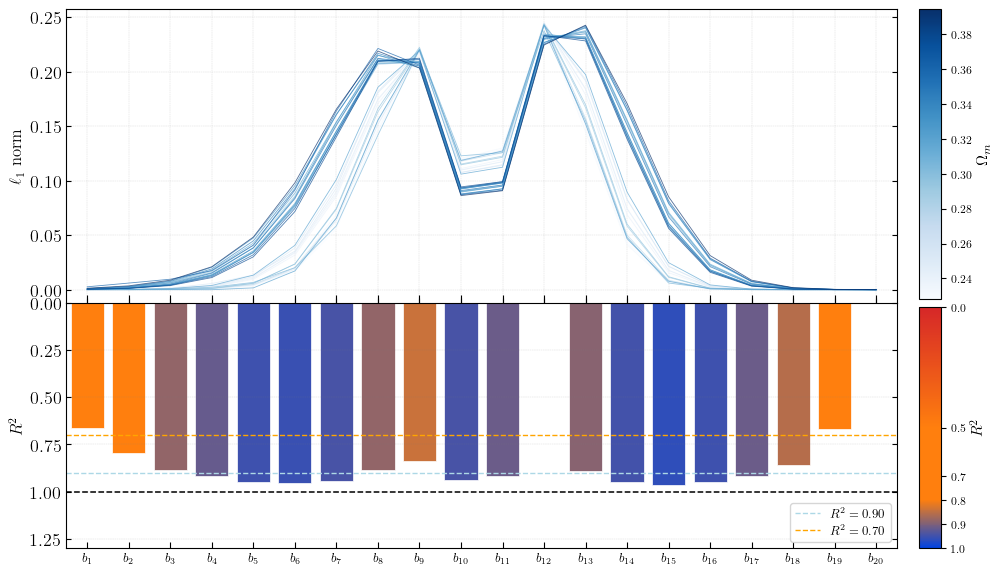

In [13]:
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

# ── Custom R² colormap ────────────────────────────────────────────────────────
r2_cmap = LinearSegmentedColormap.from_list(
    "r2_custom",
    [(0.0, "#d62728"), (0.5, "#ff7f0e"), (0.8, "#ff7f0e"), (1.0, "#0343df")]
)

bin_cols  = [f"bin_{i}" for i in range(N_BINS)]
dv_matrix = csv_data[bin_cols].to_numpy()
om_vals   = csv_data["Omega_m"].to_numpy()
om_norm   = Normalize(vmin=om_vals.min(), vmax=om_vals.max())
dv_cmap   = plt.cm.Blues
x_bins    = np.arange(1, N_BINS + 1)

# ── Figure ────────────────────────────────────────────────────────────────────
fig_r2, (ax_dv, ax_r2) = plt.subplots(
    2, 1, figsize=(11, 7), sharex=True,
    gridspec_kw={"height_ratios": [1.2, 1], "hspace": 0},
)

# ── Top: data vectors ─────────────────────────────────────────────────────────
for idx in np.argsort(om_vals):
    ax_dv.plot(x_bins, dv_matrix[idx],
               color=dv_cmap(om_norm(om_vals[idx])),
               lw=0.6, alpha=0.7)

ax_dv.set_xlim(0.5, N_BINS + 0.5)
ax_dv.set_ylabel(r"$\ell_1$ norm", fontsize=12)
ax_dv.tick_params(which="both", top=True, right=True, direction="in")
ax_dv.grid(True, lw=0.3, ls="--", alpha=0.35, color="gray")
ax_dv.spines["bottom"].set_visible(False)
ax_dv.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

# ── Join axis: ticks on BOTH sides of the boundary ───────────────────────────
ax_join = ax_dv.twiny()
ax_join.set_xlim(ax_dv.get_xlim())
ax_join.xaxis.set_ticks_position("bottom")
ax_join.xaxis.set_label_position("bottom")
ax_join.spines["bottom"].set_position(("axes", 0))
ax_join.spines["top"].set_visible(False)
ax_join.spines["left"].set_visible(False)
ax_join.spines["right"].set_visible(False)
ax_join.set_xticks(x_bins)
ax_join.set_xticklabels([])                        # no labels here — labels at bottom
ax_join.tick_params(axis="x", which="both",
                    direction="in",             # ← ticks poke both up and down
                    top=False, bottom=True,
                    length=6, width=0.8)

# ── Bottom: R² bars hanging downward ─────────────────────────────────────────
norm_r2    = Normalize(vmin=0, vmax=1)
bar_colors = [r2_cmap(norm_r2(r)) for r in all_r2]

ax_r2.bar(x_bins, all_r2, color=bar_colors, edgecolor="white",
          linewidth=0.5, width=0.8)

ax_r2.axhline(1.0, color="k",         lw=1.1, ls="--")
ax_r2.axhline(0.9, color="lightblue", lw=1.0, ls="--", label=r"$R^2=0.90$")
ax_r2.axhline(0.7, color="orange",    lw=1.0, ls="--", label=r"$R^2=0.70$")

ax_r2.set_ylim(1.3, 0)                             # ← 0 at bottom, 1.3 at top (inverted)
ax_r2.set_ylabel(r"$R^2$", fontsize=12)
ax_r2.tick_params(which="both", top=False, right=True, direction="in")
ax_r2.grid(True, lw=0.3, ls="--", alpha=0.35, color="gray", axis="y")
ax_r2.legend(fontsize=9, loc="lower right")
ax_r2.spines["top"].set_visible(False)

# ── Bottom x-axis: labels here ───────────────────────────────────────────────
ax_r2.tick_params(axis="x", which="both",
                  bottom=True, labelbottom=True,   # ← ticks + labels at bottom
                  direction="in", length=4)
ax_r2.set_xticks(x_bins)
ax_r2.set_xticklabels([rf"$b_{{{i}}}$" for i in x_bins], fontsize=9)

# ── Colorbars: small gap between them ────────────────────────────────────────
fig_r2.subplots_adjust(right=0.88)

pos_dv = ax_dv.get_position()
pos_r2 = ax_r2.get_position()

gap    = 0.012                                     # ← separation between colorbars
cax_dv = fig_r2.add_axes([0.90, pos_dv.y0 + gap/2, 0.02, pos_dv.height - gap/2])
cax_r2 = fig_r2.add_axes([0.90, pos_r2.y0,         0.02, pos_r2.height - gap/2])

sm_dv = ScalarMappable(cmap=dv_cmap, norm=om_norm)
sm_dv.set_array([])
cbar_dv = fig_r2.colorbar(sm_dv, cax=cax_dv)
cbar_dv.set_label(r"$\Omega_m$", fontsize=11)
cbar_dv.ax.tick_params(labelsize=8)

sm_r2 = ScalarMappable(cmap=r2_cmap, norm=norm_r2)
sm_r2.set_array([])
cbar_r2 = fig_r2.colorbar(sm_r2, cax=cax_r2)
cbar_r2.set_label(r"$R^2$", fontsize=11)
cbar_r2.set_ticks([0, 0.5, 0.7, 0.8, 0.9, 1.0])
cbar_r2.ax.tick_params(labelsize=8)
cbar_r2.ax.invert_yaxis()

fig_r2.savefig("r2_bar_chart.pdf", bbox_inches="tight", dpi=200)
plt.show()

Scaler mean:   [ 0.30345436  0.76762189 -1.00377209]
Scaler scale:  [0.05187915 0.08028369 0.09066962]


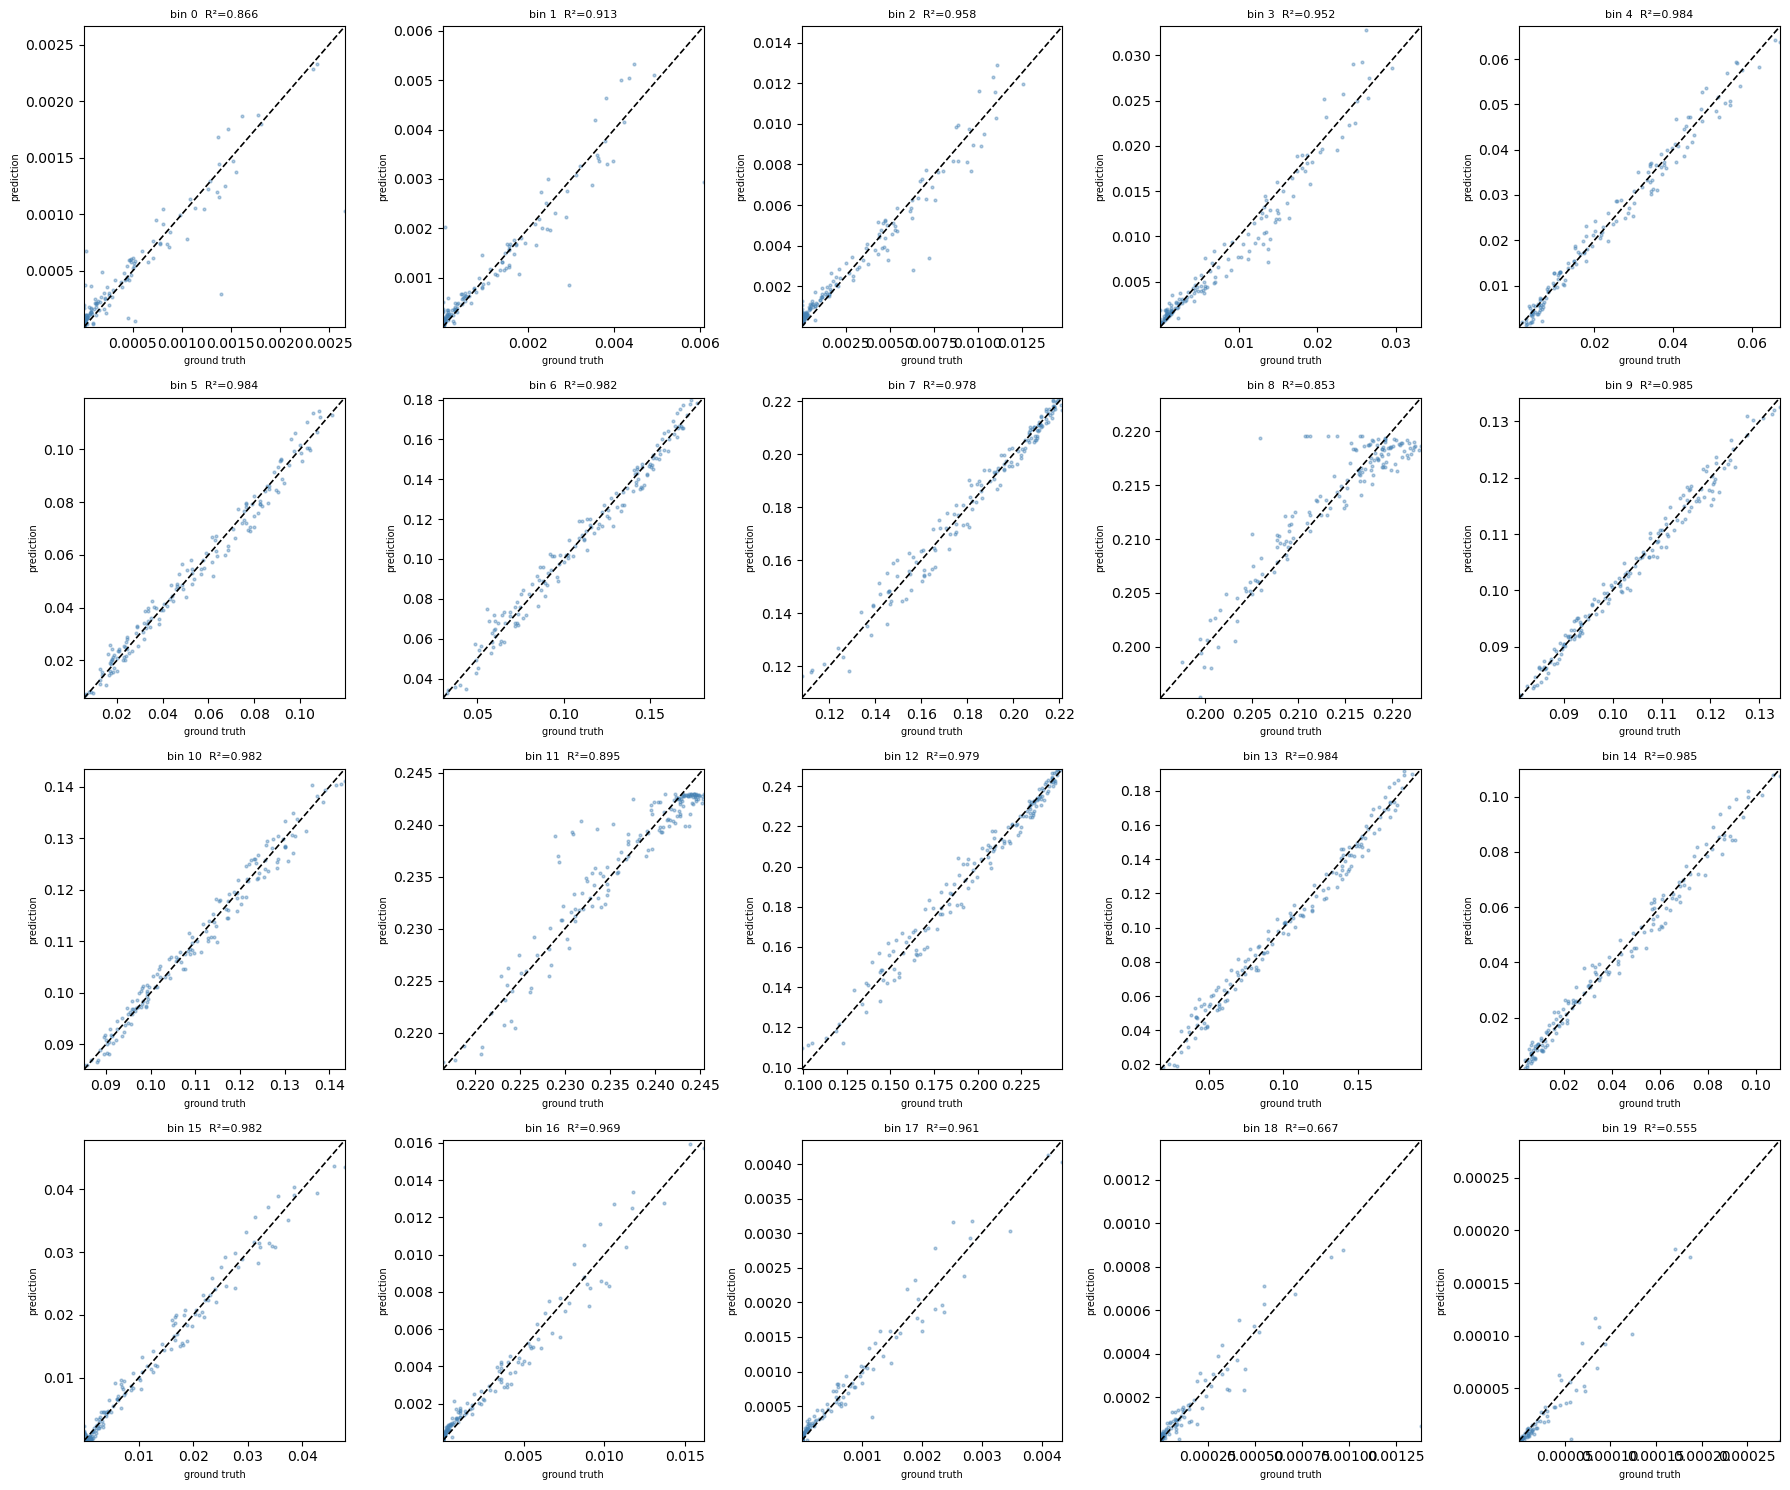

In [ ]:
from sklearn.preprocessing import StandardScaler

csv_data = pd.read_csv('/Users/arnablahiry/repos/SR_project/data/csv/l1norm_training_data_b20.csv')

Om_data = csv_data['Omega_m'].to_numpy()
s8_data = csv_data['sigma_8'].to_numpy()
w_data  = csv_data['w'].to_numpy()

# ── Replicate the exact StandardScaler from l1norm_sr.py ──────────────────
# SR saw X_scaled = scaler.fit_transform(X.T).T  where X = (3, N_samples)
X_raw    = np.stack([Om_data, s8_data, w_data], axis=1)  # (N_samples, 3)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)                   # (N_samples, 3)

# Unpack scaled columns — these are what the SR expressions expect
Om_scaled = X_scaled[:, 0]
s8_scaled = X_scaled[:, 1]
w_scaled  = X_scaled[:, 2]

print("Scaler mean:  ", scaler.mean_)
print("Scaler scale: ", scaler.scale_)

# ── Sympy symbols ──────────────────────────────────────────────────────────
_Om, _s8, _w, _c0, _c1, _c2 = sp.symbols("Omega_m sigma_8 w c0 c1 c2", real=True)
SYMPY_VARS = {"Omega_m": _Om, "sigma_8": _s8, "w": _w,
              "c0": _c0, "c1": _c1, "c2": _c2}

NUMPY_MAP = [
    {"exp": np.exp, "log": np.log, "log2": np.log2, "log10": np.log10,
     "sqrt": np.sqrt, "abs": np.abs, "Abs": np.abs, "sin": np.sin,
     "cos": np.cos, "tan": np.tan, "tanh": np.tanh, "sinh": np.sinh,
     "cosh": np.cosh, "sign": np.sign},
    "numpy",
]

N_BINS = 20; N_FREE_PARAMS = 3; LENGTH_LOC_ARG = 10
LENGTH_SCALE_ARG = 5; SEED = 42; RESIDUAL_MODE = False

rows = [-3,-4, 3, 3, -2, -3, 3, -1, -1, -2, 3, -1, -1, -1, -4, -2, 3, -1, -1, -1]

fig, axes = plt.subplots(4, 5, figsize=(18, 15))
axes = axes.flatten()

for bin_idx in range(N_BINS):
    gt = csv_data[f'bin_{bin_idx}'].to_numpy().astype(float)

    folder_name = (
        "/Users/arnablahiry/repos/SR_project/y_all_syms/"
        "L1NORM_SR_bin%d_of%d_res%i_fp%d_lloc%d_lscale%d_s%d"
        % (bin_idx, N_BINS, int(RESIDUAL_MODE), N_FREE_PARAMS,
           LENGTH_LOC_ARG, LENGTH_SCALE_ARG, SEED)
    )
    row = pd.read_csv(
        os.path.join(folder_name, "sr_curves_pareto.csv")
    ).iloc[rows[bin_idx]]

    c0_val, c1_val, c2_val = float(row['c0']), float(row['c1']), float(row['c2'])

    sym_expr = sp.sympify(row["expression"], locals=SYMPY_VARS)
    func = sp.lambdify((_Om, _s8, _w, _c0, _c1, _c2), sym_expr, modules=NUMPY_MAP)

    # ── Pass SCALED inputs — matching what SR was trained on ──────────────
    pred = func(Om_scaled, s8_scaled, w_scaled, c0_val, c1_val, c2_val)
    pred = np.asarray(pred, dtype=float).ravel()

    r2 = 1 - np.sum((gt - pred)**2) / np.sum((gt - np.mean(gt))**2)

    ax = axes[bin_idx]
    lo, hi = gt.min(), gt.max()
    ax.scatter(gt, pred, s=4, alpha=0.4, color="steelblue")
    ax.plot([lo, hi], [lo, hi], "k--", lw=1.2)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_title(f"bin {bin_idx}  R²={r2:.3f}", fontsize=8)
    ax.set_xlabel(r"Ground Truth $\ell_1$ norm", fontsize=12)
    ax.set_ylabel(r"Ground Truth $\ell_1$ norm",   fontsize=12)

plt.tight_layout()
plt.show()


Facet plot saved as 'prediction_vs_truth_facets.png'


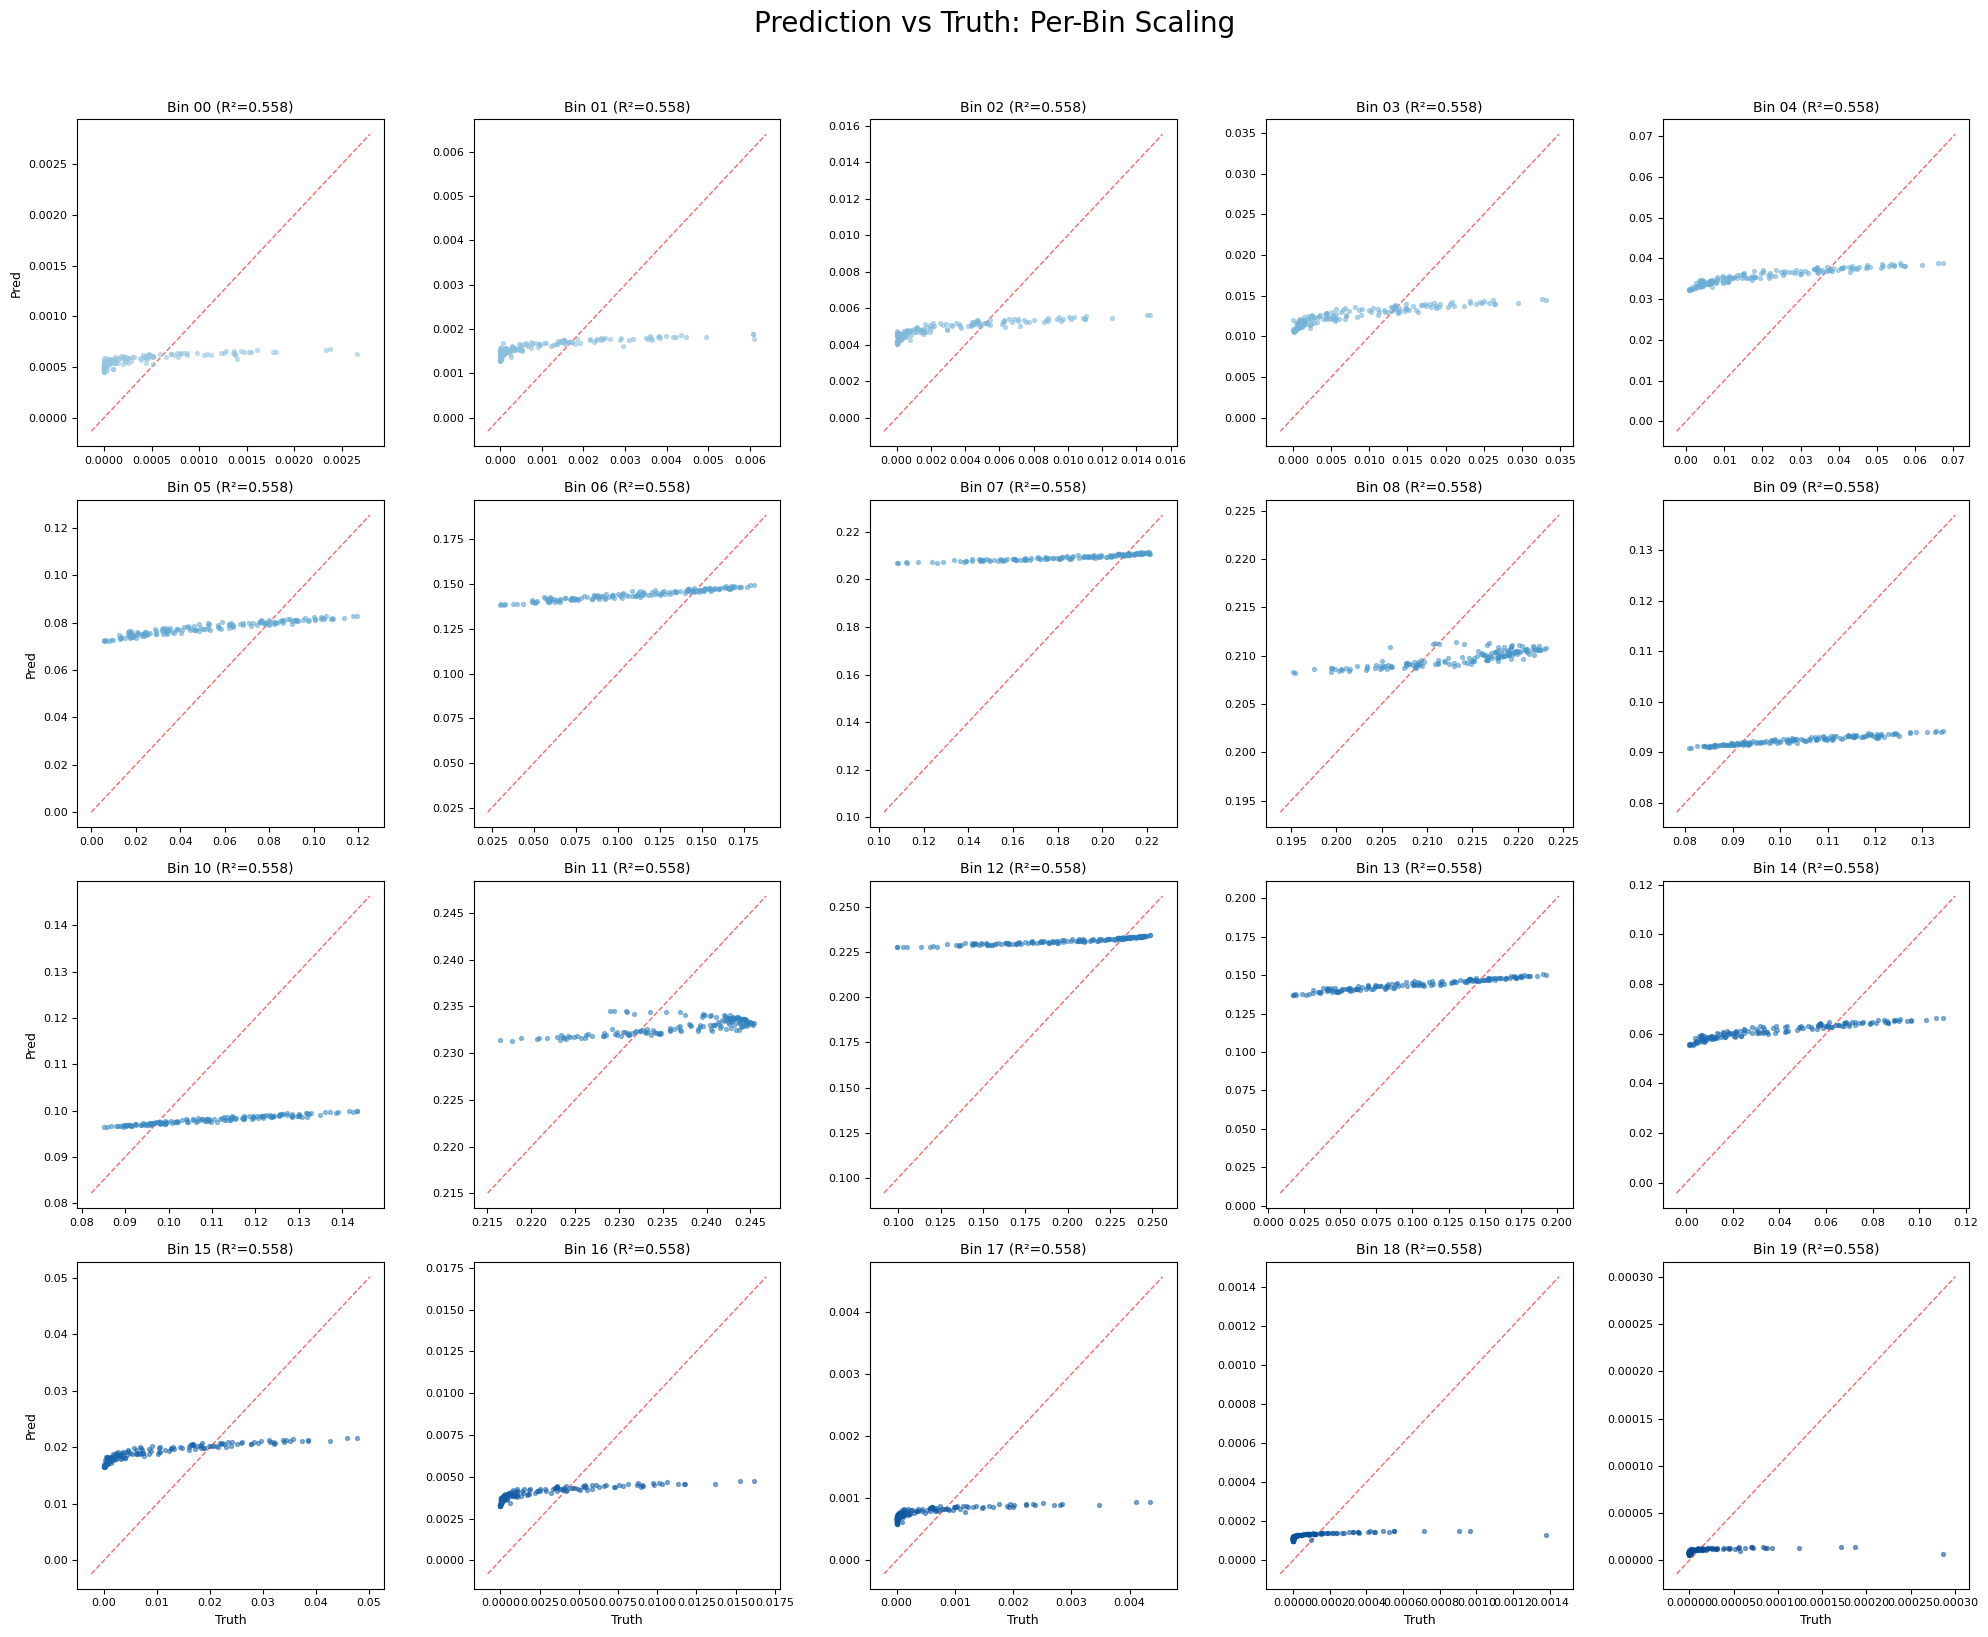

In [33]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ── 5. Setup Facet Grid (4 rows, 5 columns for 20 bins) ──────────────────
fig, axes = plt.subplots(4, 5, figsize=(20, 16), sharex=False, sharey=False)
axes = axes.flatten()

# Generate sequential shades of blue
colors = cm.Blues(np.linspace(0.4, 0.9, 20))

for bin_idx in range(20):
    ax = axes[bin_idx]
    
    truth = csv_data[f'bin_{bin_idx}'].to_numpy()
    pred = all_results[bin_idx]
    
    # Calculate local axis limits for the truth line
    margin = 0.05
    all_vals = np.concatenate([truth, pred])
    v_min, v_max = all_vals.min(), all_vals.max()
    v_range = v_max - v_min
    
    plot_min = v_min - margin * v_range
    plot_max = v_max + margin * v_range
    
    # Plot Identity Line (y=x)
    ax.plot([plot_min, plot_max], [plot_min, plot_max], 
            color='red', linestyle='--', alpha=0.6, linewidth=1, zorder=1)
    
    # Plot Scatter
    ax.scatter(truth, pred, color=colors[bin_idx], alpha=0.5, s=8, zorder=2, rasterized=True)
    
    # Labeling
    ax.set_title(f"Bin {bin_idx:02d} (R²={row['r2']:.3f})", fontsize=10)
    ax.tick_params(axis='both', which='major', labelsize=8)
    
    # Only label outer axes to save space
    if bin_idx >= 15: ax.set_xlabel("Truth", fontsize=9)
    if bin_idx % 5 == 0: ax.set_ylabel("Pred", fontsize=9)

# ── 6. Global Formatting ─────────────────────────────────────────────────
plt.suptitle("Prediction vs Truth: Per-Bin Scaling", fontsize=20, y=1.02)
plt.tight_layout()

plt.savefig("prediction_vs_truth_facets.png", dpi=300, bbox_inches='tight')
print("\nFacet plot saved as 'prediction_vs_truth_facets.png'")
plt.show()

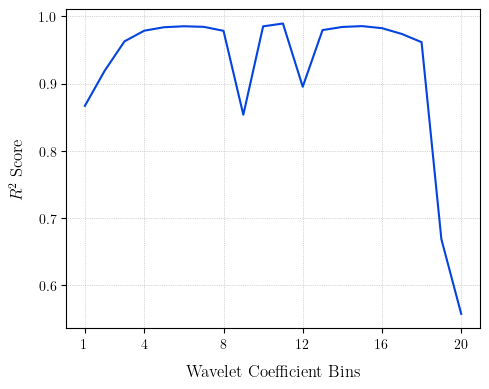

In [44]:
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

fig, ax = plt.subplots(figsize=(5, 4))

ax.plot(np.arange(1, 21), all_r2, color='xkcd:blue')
ax.set_xticks([1, 4, 8, 12, 16, 20])
ax.grid(linestyle=':', linewidth=0.5)
ax.set_xlabel(r'Wavelet Coefficient Bins', labelpad=10, fontsize=12)
ax.set_ylabel(r'$R^2$ Score', usetex=True, labelpad=10, fontsize=12)

plt.tight_layout()
plt.show()